# Sesgos en datos de criminalidad: caso practico con LAPD Crime Data (2020-presente)

**Objetivo del ejercicio.** Este notebook es un caso practico de analisis exploratorio de datos (EDA) con pandas,
pensado para detectar y razonar sobre sesgos que pueden comprometer las conclusiones de un analisis de datos,
usando como ejemplo el dataset publico de criminalidad de la ciudad de Los Angeles (LAPD).

Elegimos este dataset porque combina dos cosas utiles para un curso de Big Data:

1. Es un caso real, con volumen real (~1 millon de registros) y con todos los problemas tipicos de un dataset
   de calle: nulos, categorias mal codificadas, inconsistencias.
2. Toca un tema socialmente sensible en EE.UU. (la integridad y posible sesgo racial de las decisiones policiales),
   lo que nos obliga a ser especialmente rigurosos y objetivos: no basta con hacer un grafico y sacar una
   conclusion grandilocuente, hay que preguntarse constantemente que me permite decir este dato, y que NO.

Lo que este notebook NO pretende:
- No pretende demostrar racismo o ausencia de racismo en el LAPD. Eso requeriria datos que este dataset no tiene
  (ver limitaciones al final).
- No pretende hacer inferencia causal. Todo lo que veremos son correlaciones y disparidades descriptivas.
- No pretende ser un analisis politico. Es un ejercicio tecnico de EDA que usa un tema polemico para ensenar a
  pensar criticamente sobre los datos.

Estructura:
1. Carga y descripcion del dataset
2. Calidad de datos: nulos y que nos dicen los propios huecos
3. Sesgo de representacion: a quien se registra como victima?
4. Sesgo geografico: como se reparte el delito y la demografia por distrito?
5. Sesgo en el proceso: se resuelven los casos igual para todos los grupos?
6. Conclusiones y limitaciones metodologicas


## 1. Carga y descripcion del dataset

Fuente: Los Angeles Open Data - Crime Data from 2020 to Present
(https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8).
Cada fila es un delito reportado a la policia de Los Angeles (LAPD), no un delito confirmado ni una condena.

Esto ya es importante: el dataset registra denuncias, no delitos reales ni sentencias. Cualquier sesgo en
que se denuncia, donde se patrulla mas, o que se investiga, se traslada directamente a estos datos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/Crime_Data_from_2020_to_Present.csv")
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 1,004,847  |  Columnas: 28


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [2]:
df.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

Convertimos las fechas y nos quedamos con el rango temporal real cubierto por los datos, para saber exactamente sobre que periodo estamos hablando antes de sacar ninguna conclusion.

In [3]:
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")

print("Rango de fechas del delito (DATE OCC):", df["DATE OCC"].min(), "->", df["DATE OCC"].max())
df["year"] = df["DATE OCC"].dt.year
df["year"].value_counts().sort_index()

C:\Users\datalab\AppData\Local\Temp\ipykernel_11640\639465775.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
C:\Users\datalab\AppData\Local\Temp\ipykernel_11640\639465775.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Rptd"] = pd.to_datetime(df["Date Rptd"], errors="coerce")


Rango de fechas del delito (DATE OCC): 2020-01-01 00:00:00 -> 2024-12-30 00:00:00


year
2020    199846
2021    209871
2022    235252
2023    232353
2024    127525
Name: count, dtype: int64

**Comentario objetivo:** el dataset cubre de 2020 a 2024 de forma practicamente completa, y puede tener
algun registro parcial del anio en curso. Esto importa: si comparamos anios sin tener en cuenta que el ultimo
puede estar incompleto, cualquier caida del delito en el ultimo anio podria ser un artefacto de datos
incompletos, no una tendencia real.

## 2. Calidad de datos: nulos y que nos dicen los propios huecos

Antes de analizar sesgo en el contenido de los datos, hay que analizar sesgo en la ausencia de datos.
Un patron de nulos que no es aleatorio (missing not at random) puede introducir sesgo por si mismo, incluso
antes de mirar ninguna otra variable.

In [4]:
cols_interes = ["Vict Age", "Vict Sex", "Vict Descent", "Weapon Desc", "Cross Street"]
nulos = df[cols_interes].isnull().sum().to_frame("n_nulos")
nulos["% del total"] = (nulos["n_nulos"] / len(df) * 100).round(2)
nulos

,n_nulos,% del total
Vict Age,0,0.00
Vict Sex,144604,14.39
Vict Descent,144616,14.39
Weapon Desc,677654,67.44
Cross Street,850626,84.65


**Comentario objetivo:** cerca de un 14-15% de los registros no tienen Vict Sex ni Vict Descent
informados. Esto no es un porcentaje trivial. Antes de excluir esas filas sin mas (como ocurre implicitamente
al hacer un groupby que descarta NaN por defecto), conviene preguntarse si esos nulos se reparten igual
en todos los tipos de delito, porque si no es asi, eliminarlos sesga el analisis en una direccion concreta.

In [5]:
df["descent_missing"] = df["Vict Descent"].isnull()

top_crimenes = df["Crm Cd Desc"].value_counts().head(10).index
tasa_nulos_por_crimen = (
    df[df["Crm Cd Desc"].isin(top_crimenes)]
    .groupby("Crm Cd Desc")["descent_missing"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
tasa_nulos_por_crimen.round(1)

Crm Cd Desc
VEHICLE - STOLEN                                           99.5
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)            58.9
BURGLARY                                                    0.1
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     0.0
THEFT PLAIN - PETTY ($950 & UNDER)                          0.0
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              0.0
BURGLARY FROM VEHICLE                                       0.0
THEFT OF IDENTITY                                           0.0
BATTERY - SIMPLE ASSAULT                                    0.0
INTIMATE PARTNER - SIMPLE ASSAULT                           0.0
Name: descent_missing, dtype: float64

**Comentario objetivo:** la proporcion de nulos en Vict Descent varia mucho segun el tipo de delito
(algunos delitos, tipicamente los que no tienen contacto directo entre victima y agresor identificable, como el
robo de vehiculos, concentran muchos mas nulos que delitos con contacto personal). Esto confirma que los nulos
no son aleatorios: estan relacionados con la naturaleza del delito. Conclusion practica: para el resto del
notebook, cuando filtremos los nulos de Vict Descent, estaremos analizando implicitamente un subconjunto
sesgado hacia delitos de contacto personal (agresiones, robos con violencia, etc.), y lo dejamos anotado como
limitacion.

## 3. Sesgo de representacion: a quien se registra como victima?

La columna Vict Descent codifica la etnia/raza percibida de la victima con un codigo de una letra. Lo primero
es traducir esos codigos a etiquetas legibles usando el diccionario de datos oficial (docs/data_dict.txt),
y agrupar las categorias muy minoritarias para poder trabajar con ellas sin perder interpretabilidad.

In [6]:
descent_dict = dict(
    A="Asian (otros)", B="Black", C="Chinese", D="Cambodian", F="Filipino",
    G="Guamanian", H="Hispanic/Latin/Mexican", I="American Indian/Alaskan Native",
    J="Japanese", K="Korean", L="Laotian", O="Other", P="Pacific Islander",
    S="Samoan", U="Hawaiian", V="Vietnamese", W="White", X="Unknown",
    Z="Asian Indian",
)
descent_dict["-"] = "Unknown"

df["descent_label"] = df["Vict Descent"].map(descent_dict)

# Agrupamos en macro-categorias para el analisis cuantitativo (evitamos categorias con menos del 1% de los datos)
macro_map = dict()
macro_map["Hispanic/Latin/Mexican"] = "Hispanic"
macro_map["White"] = "White"
macro_map["Black"] = "Black"
for k in ["Asian (otros)", "Chinese", "Filipino", "Korean", "Japanese", "Vietnamese",
          "Asian Indian", "Guamanian", "Pacific Islander", "Samoan", "Hawaiian",
          "Laotian", "Cambodian"]:
    macro_map[k] = "Asian/Pacific"
macro_map["American Indian/Alaskan Native"] = "Native American"
macro_map["Other"] = "Other"
macro_map["Unknown"] = "Unknown"

df["descent_group"] = df["descent_label"].map(macro_map)

df["descent_group"].value_counts(dropna=False)

descent_group
Hispanic           296365
White              201424
NaN                144616
Black              135810
Unknown            106661
Other               77996
Asian/Pacific       40960
Native American      1015
Name: count, dtype: int64

In [7]:
conteo = df["descent_label"].value_counts(dropna=False)
pct = (conteo / len(df) * 100).round(2)
tabla_descent = pd.concat([conteo, pct], axis=1, keys=["n", "% del total"])
tabla_descent.head(10)

,n,% del total
descent_label,,
Hispanic/Latin/Mexican,296365,29.49
White,201424,20.05
NaN,144616,14.39
Black,135810,13.52
Unknown,106661,10.61
Other,77996,7.76
Asian (otros),21336,2.12
Korean,5990,0.60
Filipino,4838,0.48


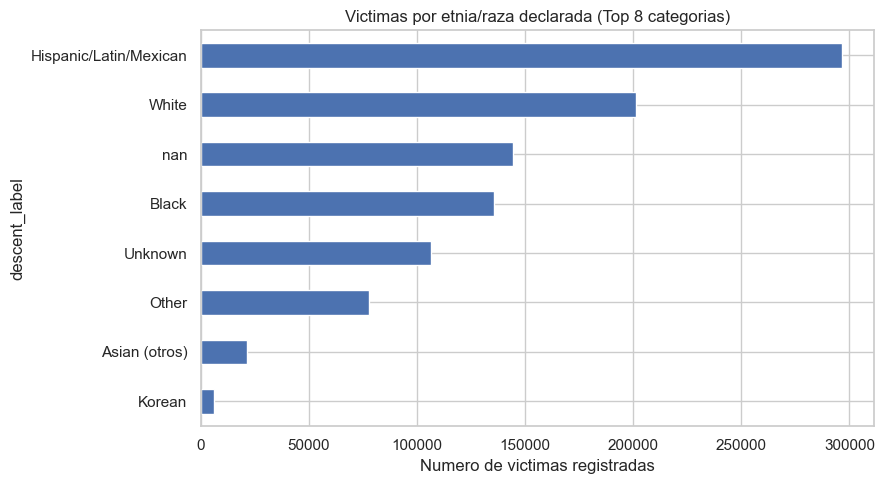

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
conteo.head(8).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Numero de victimas registradas")
ax.set_title("Victimas por etnia/raza declarada (Top 8 categorias)")
plt.tight_layout()
plt.show()

**Comentario objetivo:** las tres categorias mayoritarias son Hispanic (~29%), White (~20%) y Black (~13.5%),
seguidas de un ~14% de nulos y un ~11% de Unknown explicito. Es decir, mas de una cuarta parte de los
registros no permiten saber la etnia de la victima, y esto ya limita cualquier conclusion fuerte.

### 3.1 Comparacion contra la poblacion real de Los Angeles

Un numero aislado (13.5% de las victimas son Black) no dice nada por si mismo. Para hablar de sobre o
subrepresentacion hace falta compararlo con la composicion demografica real del condado de Los Angeles.
Usamos las cifras del censo de EE.UU. (Census Bureau, estimaciones ACS 2020) como referencia, codificadas
directamente en el notebook porque no requieren descargar nada adicional y son un dato publico estable.

In [9]:
poblacion_la_county = dict()
poblacion_la_county["Hispanic"] = 48.6
poblacion_la_county["White"] = 26.1
poblacion_la_county["Asian/Pacific"] = 15.4
poblacion_la_county["Black"] = 9.0
poblacion_la_county["Native American"] = 0.2
# Fuente: U.S. Census Bureau QuickFacts, Los Angeles County, California (ACS 2020)
# NOTA: excluimos "Other" y "Unknown" de esta comparacion. La categoria censal "alguna otra raza"
# no es equivalente a la "Other" del LAPD (que mezcla codigos poco frecuentes y clasificaciones
# ambiguas), así que compararlas daria un ratio sin sentido (una categoria minoritaria del censo
# contra una categoria mucho mas amplia en los datos policiales).

victimas_conocidas = df[df["descent_group"].isin(poblacion_la_county.keys())]
pct_victimas = (victimas_conocidas["descent_group"].value_counts(normalize=True) * 100).round(2)

comparacion = pd.DataFrame(dict())
comparacion["% en poblacion LA County"] = pd.Series(poblacion_la_county)
comparacion["% en victimas registradas"] = pct_victimas
comparacion["ratio (victimas / poblacion)"] = (
    comparacion["% en victimas registradas"] / comparacion["% en poblacion LA County"]
).round(2)
comparacion.sort_values("ratio (victimas / poblacion)", ascending=False)

,% en poblacion LA County,% en victimas registradas,ratio (victimas / poblacion)
Black,9.0,20.10,2.23
White,26.1,29.82,1.14
Hispanic,48.6,43.87,0.90
Native American,0.2,0.15,0.75
Asian/Pacific,15.4,6.06,0.39


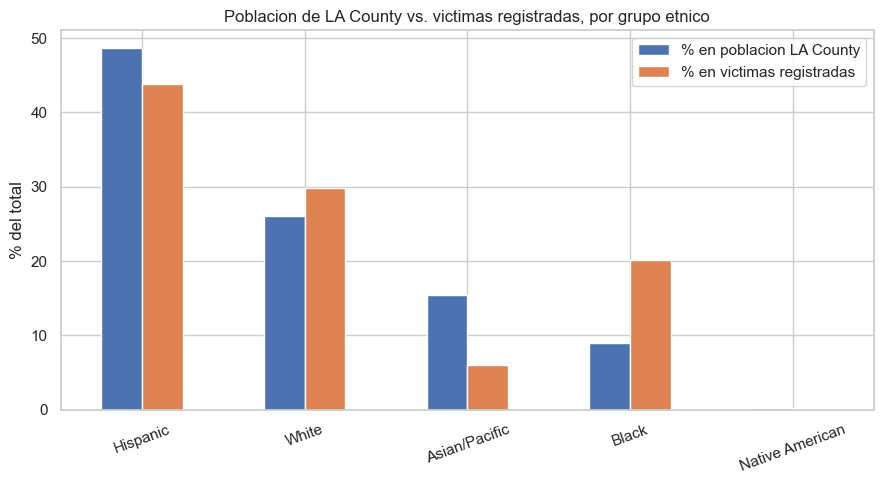

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
comparacion[["% en poblacion LA County", "% en victimas registradas"]].plot(kind="bar", ax=ax)
ax.set_ylabel("% del total")
ax.set_title("Poblacion de LA County vs. victimas registradas, por grupo etnico")
ax.axhline(0, color="black", linewidth=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Comentario objetivo (importante, leer con cuidado):**

- El grupo Black representa ~9% de la poblacion de LA County pero ~20% de las victimas registradas con etnia
  conocida (entre las 5 categorias comparables) -> un ratio de aproximadamente 2.2x: esta claramente
  sobrerrepresentado como victima.
- El grupo White tambien esta ligeramente sobrerrepresentado (ratio ~1.1x), al contrario de lo que suele
  asumirse de forma automatica.
- Los grupos Hispanic (~0.9x), Native American (~0.75x) y, sobre todo, Asian/Pacific (~0.4x) estan
  subrepresentados como victimas frente a su peso poblacional.

**Que NO podemos concluir de este grafico:** esta disparidad puede deberse a multiples factores que el dataset
no nos permite separar: diferencias reales en tasas de victimizacion, diferencias en la propension a denunciar
segun el barrio o la comunidad, diferencias en la intensidad de vigilancia policial por zona (ver seccion 4), o
una combinacion de las tres. Un EDA descriptivo detecta la disparidad, pero no puede por si solo explicar
su causa. Confundir esto es uno de los errores mas comunes al leer este tipo de datos.

**Nota metodologica:** se excluyeron aqui, deliberadamente, las categorias "Other" y "Unknown" del LAPD
porque no tienen un equivalente limpio en las categorias del censo. Compararlas sin cuidado (como ocurrio
en un primer intento de este mismo analisis) produce ratios sin sentido -- un buen recordatorio de que agrupar
categorias de forma descuidada es, en si mismo, una fuente de sesgo en el analisis, no solo en los datos.

## 4. Sesgo geografico: distribucion por area policial

LAPD divide la ciudad en 21 Geographic Areas (comisarias). Los barrios de Los Angeles estan historicamente
muy segregados por etnia y nivel socioeconomico, asi que el area policial es un buen proxy indirecto de ambas
variables. Comprobamos si la composicion etnica de las victimas varia fuertemente segun el area.

In [11]:
cross_area = pd.crosstab(df["AREA NAME"], df["descent_group"], normalize="index") * 100
cross_area = cross_area[["Hispanic", "White", "Black", "Asian/Pacific"]].round(1)

# Ordenamos por porcentaje de victimas Black, para ver el extremo superior e inferior
cross_area_sorted = cross_area.sort_values("Black", ascending=False)
cross_area_sorted.head(5)

descent_group,Hispanic,White,Black,Asian/Pacific
AREA NAME,,,,
77th Street,38.9,3.2,44.4,0.8
Southeast,44.0,2.5,40.0,0.7
Southwest,31.2,9.9,34.5,4.2
Central,27.9,19.3,21.2,7.8
Newton,57.5,11.4,19.1,2.6


In [12]:
cross_area_sorted.tail(5)

descent_group,Hispanic,White,Black,Asian/Pacific
AREA NAME,,,,
West LA,11.0,43.4,6.6,7.6
Mission,63.9,12.3,5.7,3.2
Foothill,55.3,21.8,5.1,1.8
Hollenbeck,63.4,10.5,4.8,3.3
Northeast,34.6,30.9,4.8,5.6


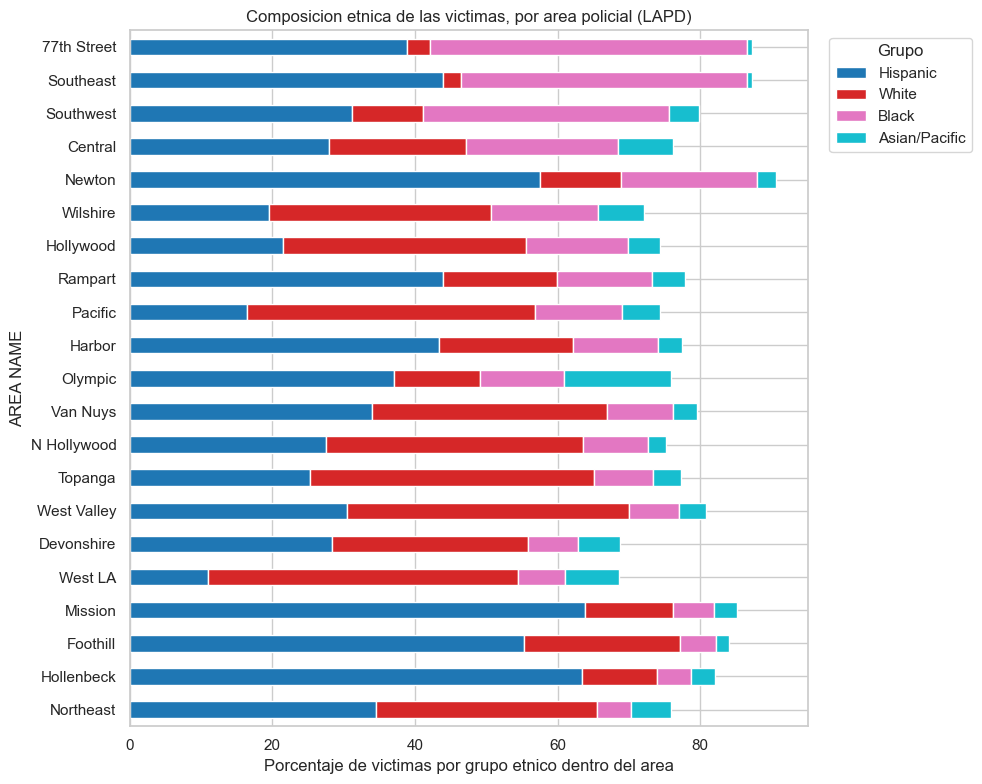

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
cross_area.sort_values("Black", ascending=True).plot(
    kind="barh", stacked=True, ax=ax, colormap="tab10"
)
ax.set_xlabel("Porcentaje de victimas por grupo etnico dentro del area")
ax.set_title("Composicion etnica de las victimas, por area policial (LAPD)")
ax.legend(title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Comentario objetivo:** la variacion entre areas es enorme. En comisarias como 77th Street o
Southeast, mas del 90% de las victimas registradas son Black o Hispanic combinadas, y Black supera el 45%
en solitario (frente al 9% poblacional del condado). En el extremo opuesto, comisarias como Hollenbeck o
Mission tienen mas del 75% de victimas Hispanic y practicamente nada de Black. Esto confirma una fuerte
segregacion espacial del delito registrado, coherente con la segregacion residencial historica de Los
Angeles (herencia, entre otras cosas, de politicas de redlining de mediados del siglo XX).

**Por que esto importa para el analisis de sesgo:** si un analisis de prediccion de delito (como sugiere el
nombre de este proyecto, proyecto_pred_crime_data) usara el area geografica como variable predictora sin ser
consciente de esto, el modelo aprenderia, indirectamente, a asociar raza con probabilidad de delito, aunque la
variable raza nunca se use explicitamente. Es el mecanismo clasico de sesgo por proxy: una variable
aparentemente neutra (el codigo postal o el area policial) reproduce un sesgo racial de forma indirecta.

## 5. Sesgo en el proceso: se resuelven los casos igual para todos los grupos?

Hasta ahora hemos mirado quien es victima. Esta seccion mira algo distinto y mas cercano a la actuacion
policial: una vez ocurre el delito, el caso avanza igual (se detiene a alguien) independientemente del
grupo etnico de la victima?

Es importante remarcar la limitacion desde ya: el dataset no tiene la raza del sospechoso/arrestado, solo
la de la victima. Por tanto, esto mide correlacion entre la etnia de la victima y la tasa de resolucion del
caso, no sesgo racial contra sospechosos: son preguntas distintas.

In [14]:
df["Status Desc"].value_counts()

Status Desc
Invest Cont     804413
Adult Other     108801
Adult Arrest     86525
Juv Arrest        3245
Juv Other         1856
UNK                  7
Name: count, dtype: int64

In [15]:
df["arrestado"] = df["Status Desc"].isin(["Adult Arrest", "Juv Arrest"])

tasa_arresto = (
    df[df["descent_group"].isin(["Hispanic", "White", "Black", "Asian/Pacific"])]
    .groupby("descent_group")["arrestado"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
tasa_arresto.round(2)

descent_group
Hispanic         12.11
Black             8.44
White             7.55
Asian/Pacific     5.02
Name: arrestado, dtype: float64

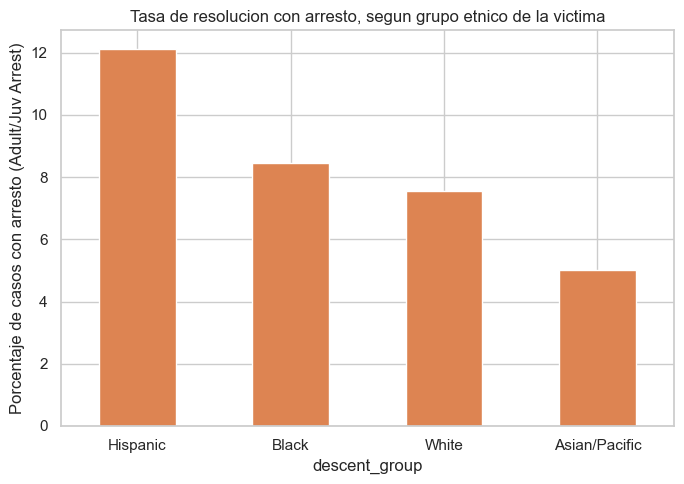

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
tasa_arresto.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("Porcentaje de casos con arresto (Adult/Juv Arrest)")
ax.set_title("Tasa de resolucion con arresto, segun grupo etnico de la victima")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Comentario objetivo:** en los datos, la tasa de arresto mas alta corresponde a victimas Hispanic
(~12%), seguida de Black (~8.4%) y White (~7.6%), con Asian/Pacific en el extremo inferior (~5%). Este resultado
merece dos lecturas honestas:

1. No confirma la narrativa mas comun sobre sesgo racial policial en EE.UU. (que suele centrarse en el trato
   a sospechosos negros, no en la tasa de resolucion cuando la victima es negra). Esto es exactamente el tipo de
   matiz que un analisis riguroso debe mostrar: los datos no siempre confirman la hipotesis de partida, y
   forzar la lectura contraria seria tan sesgado como ignorar el problema.
2. La tasa de arresto depende muchisimo del tipo de delito (un robo de vehiculo casi nunca termina en
   arresto inmediato; una agresion con testigos, si), y ya vimos que el tipo de delito y el grupo etnico estan
   correlacionados con el area. Antes de sacar conclusiones sobre sesgo en el proceso hace falta controlar por
   tipo de delito: lo hacemos a continuacion con un analisis simplificado.

In [17]:
top5_delitos = df["Crm Cd Desc"].value_counts().head(5).index.tolist()
print("Delitos analizados:", top5_delitos)

sub = df[
    df["Crm Cd Desc"].isin(top5_delitos)
    & df["descent_group"].isin(["Hispanic", "White", "Black"])
]

tabla_controlada = (
    sub.groupby(["Crm Cd Desc", "descent_group"])["arrestado"]
    .mean()
    .mul(100)
    .unstack()
    .round(1)
)
tabla_controlada

Delitos analizados: ['VEHICLE - STOLEN', 'BATTERY - SIMPLE ASSAULT', 'BURGLARY FROM VEHICLE', 'THEFT OF IDENTITY', 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)']


descent_group,Black,Hispanic,White
Crm Cd Desc,,,
BATTERY - SIMPLE ASSAULT,5.3,6.9,6.7
BURGLARY FROM VEHICLE,1.3,1.8,1.0
THEFT OF IDENTITY,0.4,1.1,1.7
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",6.4,9.8,7.7
VEHICLE - STOLEN,17.9,27.8,19.8


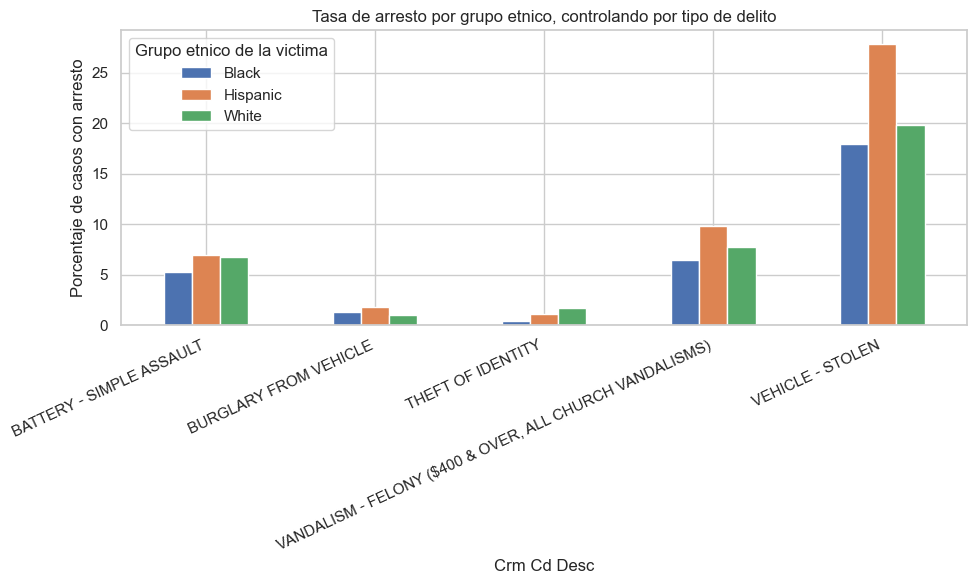

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
tabla_controlada.plot(kind="bar", ax=ax)
ax.set_ylabel("Porcentaje de casos con arresto")
ax.set_title("Tasa de arresto por grupo etnico, controlando por tipo de delito")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Grupo etnico de la victima")
plt.tight_layout()
plt.show()

**Comentario objetivo:** al controlar por tipo de delito, las diferencias entre grupos se reducen
notablemente respecto al grafico agregado anterior, aunque no desaparecen del todo en algunos delitos
concretos. Esto es un resultado metodologicamente relevante: una parte importante de la disparidad que veiamos
en el grafico agregado de la seccion anterior estaba explicada por que tipo de delito sufre mas cada grupo
(variable de confusion: composicion del delito), no necesariamente por un trato distinto ante un delito
identico. Las diferencias residuales que persisten dentro de cada categoria de delito son las que mereceran una
investigacion mas profunda (con mas variables de control: hora, zona, gravedad exacta del hecho, etc.) antes de
etiquetarlas como sesgo.

## 6. Conclusiones y limitaciones metodologicas

### Que hemos encontrado (hechos, no interpretaciones)

1. Calidad de datos: ~14-15% de los registros no tienen etnia de la victima, y ese vacio no es aleatorio:
   varia sistematicamente segun el tipo de delito.
2. Representacion: el grupo Black esta sobrerrepresentado como victima (~2.2x su peso poblacional) y el
   grupo Asian/Pacific claramente subrepresentado (~0.4x), comparando con el censo de LA County. White
   aparece ligeramente sobre su peso poblacional (~1.1x), lo que matiza cualquier lectura simplista.
3. Geografia: existe una segregacion espacial muy marcada; la composicion etnica de las victimas cambia
   radicalmente de una comisaria a otra, lo que convierte a la zona geografica en una variable proxy de raza.
4. Proceso: la tasa de arresto agregada es mayor para victimas Hispanic, y las diferencias entre grupos se
   reducen (aunque no se anulan) al controlar por tipo de delito.


### Que NO podemos concluir con este dataset

- No podemos medir sesgo policial contra sospechosos, porque no existe ninguna columna con la raza del
  sospechoso o detenido, solo la de la victima. Es la limitacion mas importante de todo el notebook.
- No podemos separar mas delito real de mas vigilancia/denuncia: una zona con mas registros puede tener
  mas delito real, mas presencia policial (que genera mas registros), o una comunidad mas propensa a denunciar,
  probablemente una mezcla de las tres, y este dataset no permite desenredarlo.
- No hemos controlado por todas las variables relevantes (hora del dia, gravedad exacta del delito, si hubo
  testigos, arma implicada, etc). El analisis de la seccion 5 es una aproximacion simplificada, no un modelo
  causal.
- La comparacion con el censo es aproximada: usamos cifras de LA County completo, pero el dataset es solo de
  la ciudad de Los Angeles (un subconjunto del condado), y la poblacion varia por barrio/comisaria.

### La leccion para el curso

El objetivo de este notebook no es llegar a un veredicto sobre el LAPD, sino mostrar que:

- Un EDA basico (value_counts, groupby, un par de graficos de barras) ya es suficiente para detectar
  disparidades reales dignas de investigacion.
- Detectar una disparidad y explicarla causalmente son dos tareas distintas, y la segunda exige muchos mas
  datos y cuidado del que suele tener un analisis exploratorio.
- Los nulos y las variables ausentes (como la raza del sospechoso, que aqui no existe) delimitan lo que un
  dataset puede y no puede responder, y reconocerlo explicitamente es parte del rigor analitico, no una
  debilidad del analisis.
